# Mock Data + MLP Regression


In [1]:
import sys
from pathlib import Path

project_root = Path(r"c:\Users\floki\PycharmProjects\dash-azure-prototype")
src_root = project_root / "src"
for p in (project_root, src_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
artifact_dir = project_root / "ml" / "models" / "artifacts" / "demo_mlp"
artifact_dir.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.datasets import make_regression

In [3]:
from ml.scripts.plotting import plot_true_vs_predicted
from ml.scripts.trainers import MLPTrainer
from worker.models.models import MLPRegressor
from worker.models.specs import ModelConfig, PreprocessConfig, AuxilaryData
from worker.models.io_utils import ArtifactIO
from worker.torch_utils import get_default_device
from ml.scripts.metrics import mape, picp
from ml.scripts.log import init_ml_logger, log_data_summary

In [4]:
# Generate demo data for testing
X, y = make_regression(
    n_samples=5000,
    n_features=20,
    n_informative=12,
    random_state=1,
)

feature_cols = [f"x{i}" for i in range(X.shape[1])]
target_cols = ["y0"]

df = pd.DataFrame(np.column_stack([X, y]), columns=[*feature_cols, *target_cols])
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x11,x12,x13,x14,x15,x16,x17,x18,x19,y0
0,0.590619,-1.141489,0.212322,0.288690,-0.540189,-0.902153,-0.296927,0.262401,-0.160685,1.399710,...,-0.038796,-0.084157,-1.079646,-1.592589,-0.417625,0.004090,-0.283232,0.704561,0.683091,49.841765
1,-0.914579,0.571446,1.729378,-0.440229,-0.989763,0.034400,1.436601,0.481986,-0.690450,-0.944504,...,0.386375,-1.362385,0.332691,-0.284159,0.237355,1.802113,1.459204,1.228611,1.580983,218.785883
2,0.116012,-0.139444,1.049639,0.320710,0.817926,-0.622471,0.865308,0.721126,0.234333,-0.274191,...,1.473116,-0.099370,0.727950,1.248064,-0.944690,1.978099,-1.216108,0.219227,0.341786,409.137182
3,-0.603507,-0.144365,-1.145753,-1.441638,-0.629680,-0.007304,-0.186908,1.169313,1.420655,-0.394762,...,1.826219,-1.533718,1.362426,0.358441,0.042161,2.063589,1.333774,-0.299368,0.167434,297.817301
4,0.191331,-1.404005,0.419711,0.740386,0.996669,1.077850,0.788490,0.000997,2.058269,0.473508,...,3.472683,-0.392867,0.622411,2.375489,-0.506324,0.337112,0.999560,0.021994,0.938939,697.566786


In [5]:
# train / validation / test split
X = df[feature_cols].to_numpy()
y = df[target_cols].to_numpy()

train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.1, random_state=1, shuffle=True
)
train_x, val_x, train_y, val_y = train_test_split(
    train_x, train_y, test_size=0.4, random_state=1
)

train_x_raw = train_x.copy()
val_x_raw = val_x.copy()
test_x_raw = test_x.copy()

train_y_raw = train_y.copy()
val_y_raw = val_y.copy()
test_y_raw = test_y.copy()

In [6]:
# feature scaling
scaler_x = MinMaxScaler()
train_x = scaler_x.fit_transform(train_x)
val_x = scaler_x.transform(val_x)
test_x = scaler_x.transform(test_x)

In [7]:
# target scaling
scaler_y = StandardScaler()
train_y = scaler_y.fit_transform(train_y)
val_y = scaler_y.transform(val_y)
test_y = scaler_y.transform(test_y)

In [8]:
# setup model
prep = PreprocessConfig(scaler_x=scaler_x, scaler_y=scaler_y)
hidden_dims = [64, 32]
dropout = 0.00
spec = ModelConfig(
    model_type="mlp_regressor",
    features=feature_cols,
    targets=target_cols,
    model_kwargs={"hidden_dims": hidden_dims, "dropout": dropout},
)
model = MLPRegressor(spec, prep)

In [9]:
# conduct training
device = get_default_device()
print(f"Running on {str(device)}")
trainer = MLPTrainer(model, device=device, lr=1e-3, weight_decay=1e-3)
metrics = trainer.train(train_x, train_y, val_x=val_x, val_y=val_y, epochs=500, early_stopping_patience=20)

Running on cuda


MLP training:   0%|          | 0/500 [00:00<?, ?it/s]

In [10]:
# check if storing / loading of artifacts works
ArtifactIO.save(artifact_dir, model=model, spec=spec, prep=prep, allow_missing_aux=True)
loaded_model = ArtifactIO.load(artifact_dir, device=device, allow_missing_aux=True)

In [11]:
# test predictions on test set
pred_mean = loaded_model.predict(test_x_raw, device=device, return_std=False)
pred_mean_train = loaded_model.predict(train_x_raw, device=device, return_std=False)

In [12]:
logger, _ = init_ml_logger(artifact_dir, "training")
if logger is not None:
    logger.info("Train time (s): %.3f", trainer.duration)
    log_data_summary(
        logger,
        train_y_raw,
        y_pred=pred_mean_train,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Train",
    )
    log_data_summary(
        logger,
        test_y_raw,
        y_pred=pred_mean,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Test",
    )

2026-03-31 11:18:57,305 | INFO | Train time (s): 2.257
2026-03-31 11:18:57,308 | INFO | Train: n_obs=2700 n_features=20 n_targets=1 non_nan_targets=2700
2026-03-31 11:18:57,311 | INFO | Train metrics per target:
2026-03-31 11:18:57,311 | INFO |   y0 | R2=0.9999 MAPE=0.0215
2026-03-31 11:18:57,311 | INFO | Test: n_obs=500 n_features=20 n_targets=1 non_nan_targets=500
2026-03-31 11:18:57,313 | INFO | Test metrics per target:
2026-03-31 11:18:57,313 | INFO |   y0 | R2=0.9999 MAPE=0.1225


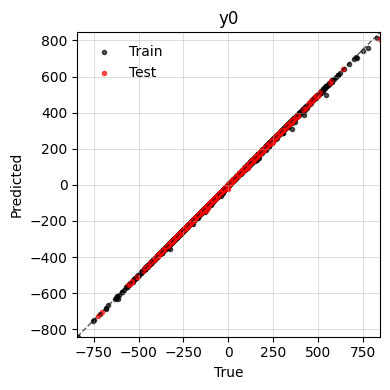

In [13]:
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plot_true_vs_predicted(
    train_y_raw,
    pred_mean_train,
    y_true_test=test_y_raw,
    y_pred_test=pred_mean,
    target_cols=target_cols,
    show_std=False,
    filepath=plots_dir / "results",
)